In [1]:
import os
import torch 
import torch.nn as nn
from spnc import spnc_anisotropy
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle
import spnc_ml as ml


from pathlib import Path

CANDIDATES = [
    
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)

from deterministic_mask import fixed_seed_mask, max_sequences_mask
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report

In [2]:
# 构建储层对象
class ReservoirParams:
    def __init__(self, **kwargs):
            # Reservoir parameters 
            self.h = 0.4473502275692851
            self.theta_H = 90
            self.k_s_0 = 0
            self.phi = 45
            self.beta_prime = 20

            # Network parameters 
            self.Nvirt = 30
            self.m0 = 0.007586422893538462
            self.bias = True
            self.Nwarmup = 0
            self.verbose_repr = False

            self.params = {
                'theta': 0.5540233436467944,
                'gamma': 0.13738441393289658,
                'delay_feedback': 0,
                'Nvirt': self.Nvirt,
                'length_warmup': self.Nwarmup,
                'warmup_sample': self.Nwarmup * self.Nvirt,
                'voltage_noise': False,
                'seed_voltage_noise': 1234,
                'delta_V': 0.1,
                'johnson_noise': False,
                'seed_johnson_noise': 1234,
                'mean_johnson_noise': 0.0000,
                'std_johnson_noise': 0.00001,
                'thermal_noise': False,
                'seed_thermal_noise': 1234,
                'lambda_ou': 1.0,
                'sigma_ou': 0.1
        }

            for key in ['h', 'theta_H', 'k_s_0', 'phi', 'beta_prime', 'Nvirt', 'm0', 'bias', 'Nwarmup']:
                if key in kwargs:
                    setattr(self, key, kwargs[key])

            
            if 'params' in kwargs and isinstance(kwargs['params'], dict):
                self.params.update(kwargs['params'])

    
    def update_params(self, **kwargs):
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
            if key in self.params:
                self.params[key] = value
            if not hasattr(self, key) and key not in self.params:
                raise AttributeError(f"ReservoirParams has no attribute or param key '{key}'")
            
    def print_params(self, verbose=False):
        if not verbose:
            print(f"ReservoirParams(h={self.h}, beta_prime={self.beta_prime}, Nvirt={self.Nvirt})")
        else:
            print(f"ReservoirParams detailed info:")
            print(f"  h = {self.h}")
            print(f"  theta_H = {self.theta_H}")
            print(f"  k_s_0 = {self.k_s_0}")
            print(f"  phi = {self.phi}")
            print(f"  beta_prime = {self.beta_prime}")
            print(f"  Nvirt = {self.Nvirt}")
            print(f"  m0 = {self.m0}")
            print(f"  bias = {self.bias}")
            print("  params dictionary:")
            for k, v in self.params.items():
                print(f"    {k}: {v}")

In [7]:
params = ReservoirParams(
        h=0.3438491851897433, m0=0.005884523604555656, Nvirt=20, beta_prime=37.76687573530968,
        params={'theta': 0.5883604670826516, 'gamma': 0.015600089552382755, 'Nvirt': 20}
    )

In [8]:
spn = spnc_anisotropy(
        params.h,
        params.theta_H,
        params.k_s_0,
        params.phi,
        params.beta_prime,
        restart=True
    )

transform = spn.gen_signal_slow_delayed_feedback

In [9]:
speakers = ['f1', 'f2', 'f3', 'f4', 'f5'] 

Samples for training:  500
Samples for test:  795
(11, 13)
Normalise over whole matrix
Nin = 13 , Nout =  10 , Nvirt =  20
Seed Training: 1234
error with zero =  0.07791524374179126
l= 4.5399929762484854e-05 0.07795044215260916
lambda=4.5399929762484854e-05: MSE=0.07795044215260916
Current weights: [[-13.1592772   10.84774661  19.84789596  14.58572014  13.33228543
   -3.18741991  -6.7357354  -23.3444919    1.18034026 -13.3669809 ]
 [ 15.19077527 -29.66468391 -20.10383939  -6.82264119 -26.77134651
    7.19263803 -17.66775895   0.39150985  21.99732558  56.25766666]
 [ 11.96688608  27.57371138 -20.1896042  -39.24852422 -13.59131855
  -36.65242585  47.43185523  66.26281652 -17.53013184 -26.02269894]
 [ 34.89137883 -18.47165706  -2.94821339  46.81649616  16.16209345
   45.94473682 -28.43367605 -50.84184351 -33.33221595  -9.78782631]
 [-48.48720792  -1.91501534  32.76449506   4.11538475  -2.46745789
    1.24469904 -12.3708086  -29.11049928  41.62206242  14.6050554 ]
 [ 47.52245473  38.666043

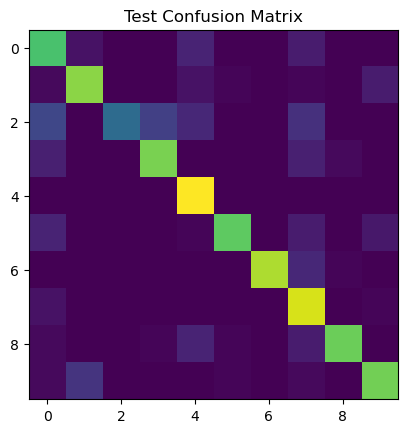

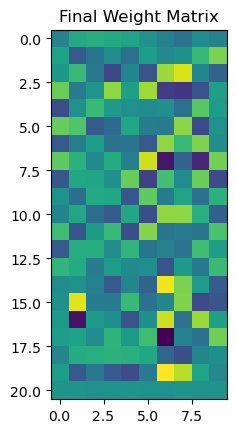

Spoken digits accuracy: 0.79


In [10]:
acc = ml.spnc_spoken_digits(speakers, params.Nvirt, params.m0, params.bias, transform, params.params, nfft = 2048, return_accuracy=True)
print(f"Spoken digits accuracy: {acc:.2f}")

In [14]:
import contextlib
import io

with contextlib.redirect_stdout(io.StringIO()):
    acc = ml.spnc_spoken_digits(speakers, params.Nvirt, params.m0, params.bias, transform, params.params, nfft=2048, return_accuracy=True, verbose=False)
print(f"Spoken digits accuracy: {acc:.2f}")

Spoken digits accuracy: 0.80


In [28]:
params_configs = {
    'beta_prime': np.arange(20, 51, 5),
    'theta': np.linspace(0.01, 10.0, 7),
    # 'gamma': np.linspace(0.01, 0.3, 7),
    'm0': np.linspace(0.001, 0.2, 7), 
#     'h': np.linspace(0.3, 0.5, 7)
}

In [29]:
beta_prime = np.arange(20, 51, 5)
print(beta_prime)
print(np.size(beta_prime))

[20 25 30 35 40 45 50]
7


In [30]:
# 在你的notebook中添加这个新的cell

import itertools
import copy
from tqdm import tqdm
import pickle
from datetime import datetime

def run_parameter_sweep(params_configs, speakers, base_params, transform,  nfft=2048, save_results=True, filename_prefix="parameter_sweep"):
    """
    遍历所有参数组合并执行spnc_spoken_digits函数
    
    Parameters:
    -----------
    params_configs : dict
        参数配置字典，格式如 {'param_name': [values]}
    speakers : list
        说话者列表
    base_params : ReservoirParams
        基础参数对象
    transform : function
        信号变换函数
    ml_module : module
        包含spnc_spoken_digits函数的模块
    nfft : int, optional
        FFT点数，默认2048
    save_results : bool, optional
        是否保存结果，默认True
    filename_prefix : str, optional
        保存文件的前缀，默认"parameter_sweep"
    
    Returns:
    --------
    results : dict
        包含所有结果的字典
    """
    
    # 获取所有参数组合
    param_names = list(params_configs.keys())
    param_values = list(params_configs.values())
    
    # 生成所有参数组合
    param_combinations = list(itertools.product(*param_values))
    
    print(f"总共需要测试 {len(param_combinations)} 种参数组合")
    print(f"参数: {param_names}")
    
    results = {
        'param_names': param_names,
        'param_values': param_values,
        'combinations': [],
        'accuracies': [],
        'configurations': []
    }
    
    # 遍历所有参数组合
    for i, combination in enumerate(tqdm(param_combinations, desc="参数扫描进度")):
        # 创建新的参数对象（通过复制base_params）
        test_params = copy.deepcopy(base_params)
        
        # 更新当前组合的参数
        param_dict = dict(zip(param_names, combination))
        test_params.update_params(**param_dict)
        
        try:
            # 执行spnc_spoken_digits函数
            with contextlib.redirect_stdout(io.StringIO()):
                acc = ml.spnc_spoken_digits(
                    speakers, 
                    test_params.Nvirt, 
                    test_params.m0, 
                    test_params.bias, 
                    transform, 
                    test_params.params,
                    nfft=nfft, 
                    return_accuracy=True
                )
            
            # 保存结果
            results['combinations'].append(combination)
            results['accuracies'].append(acc)
            results['configurations'].append(param_dict)
            
        except Exception as e:
            print(f"错误 (组合 {i+1}): {e}")
            results['combinations'].append(combination)
            results['accuracies'].append(None)
            results['configurations'].append(param_dict)
    
    # 保存结果
    if save_results:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename_prefix}_{timestamp}.pkl"
        
        with open(filename, 'wb') as f:
            pickle.dump(results, f)
        print(f"\n结果已保存到: {filename}")
    
    return results


In [31]:
# 执行参数扫描
params.Nvirt = 30
results = run_parameter_sweep(
    params_configs=params_configs,
    speakers=speakers,
    base_params=params,
    transform=transform,
    nfft=2048,
    save_results=True,
    filename_prefix="TI46_parameter_sweep"
)


总共需要测试 343 种参数组合
参数: ['beta_prime', 'theta', 'm0']


参数扫描进度:   0%|          | 0/343 [01:18<?, ?it/s]


KeyboardInterrupt: 

In [5]:
# 在你的notebook中添加这个新的cell

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

def plot_interactive_results(results):
    """
    使用plotly创建交互式图表来分析参数扫描结果
    
    Parameters:
    -----------
    results : dict
        run_parameter_sweep函数返回的结果字典
    """
    
    # 准备数据
    param_names = results['param_names']
    combinations = results['combinations']
    accuracies = results['accuracies']
    configurations = results['configurations']
    
    # 过滤掉None值
    valid_indices = [i for i, acc in enumerate(accuracies) if acc is not None]
    valid_combinations = [combinations[i] for i in valid_indices]
    valid_accuracies = [accuracies[i] for i in valid_indices]
    valid_configurations = [configurations[i] for i in valid_indices]
    
    if not valid_accuracies:
        print("没有有效的准确率结果")
        return
    
    # 创建DataFrame
    data = []
    for i, (combo, acc, config) in enumerate(zip(valid_combinations, valid_accuracies, valid_configurations)):
        row = {'accuracy': acc, 'experiment_id': i}
        for j, param_name in enumerate(param_names):
            row[param_name] = combo[j]
        data.append(row)
    
    df = pd.DataFrame(data)
    
    # 1. 准确率分布直方图
    fig1 = px.histogram(
        df, 
        x='accuracy', 
        nbins=20,
        title='准确率分布',
        labels={'accuracy': '准确率', 'count': '频次'},
        hover_data=['experiment_id']
    )
    fig1.show()
    
    # 2. 每个参数与准确率的关系（散点图）
    n_params = len(param_names)
    cols = min(3, n_params)
    rows = (n_params + cols - 1) // cols
    
    fig2 = make_subplots(
        rows=rows, 
        cols=cols,
        subplot_titles=[f'{param} vs 准确率' for param in param_names],
        vertical_spacing=0.1,
        horizontal_spacing=0.1
    )
    
    for i, param_name in enumerate(param_names):
        row = (i // cols) + 1
        col = (i % cols) + 1
        
        fig2.add_trace(
            go.Scatter(
                x=df[param_name],
                y=df['accuracy'],
                mode='markers',
                name=param_name,
                text=[f'实验 {idx}<br>{param_name}: {val}<br>准确率: {acc:.4f}' 
                      for idx, val, acc in zip(df['experiment_id'], df[param_name], df['accuracy'])],
                hovertemplate='%{text}<extra></extra>',
                marker=dict(
                    size=8,
                    opacity=0.7,
                    colorscale='Viridis',
                    color=df['accuracy'],
                    colorbar=dict(title="准确率") if i == 0 else None,
                    showscale=True if i == 0 else False
                )
            ),
            row=row, col=col
        )
        
        fig2.update_xaxes(title_text=param_name, row=row, col=col)
        fig2.update_yaxes(title_text='准确率', row=row, col=col)
    
    fig2.update_layout(
        height=300*rows,
        title_text="参数与准确率关系",
        showlegend=False
    )
    fig2.show()
    
    # 3. 参数相关性热力图
    corr_matrix = df[param_names + ['accuracy']].corr()
    
    fig3 = px.imshow(
        corr_matrix,
        text_auto=True,
        aspect="auto",
        title="参数相关性矩阵",
        color_continuous_scale='RdBu_r',
        zmin=-1, zmax=1
    )
    fig3.show()
    
    # 4. 最佳结果表格
    top_10 = df.nlargest(10, 'accuracy')
    
    fig4 = go.Figure(data=[go.Table(
        header=dict(
            values=['排名'] + param_names + ['准确率'],
            fill_color='paleturquoise',
            align='left'
        ),
        cells=dict(
            values=[list(range(1, len(top_10)+1))] + 
                   [top_10[param].round(4) for param in param_names] + 
                   [top_10['accuracy'].round(4)],
            fill_color='lavender',
            align='left'
        )
    )])
    
    fig4.update_layout(title="前10个最佳参数组合")
    fig4.show()
    
    # 5. 3D散点图（如果参数数量>=3）
    if len(param_names) >= 3:
        fig5 = px.scatter_3d(
            df,
            x=param_names[0],
            y=param_names[1],
            z=param_names[2],
            color='accuracy',
            size='accuracy',
            hover_data=param_names + ['accuracy'],
            title=f'3D参数空间 ({param_names[0]}, {param_names[1]}, {param_names[2]})',
            color_continuous_scale='Viridis'
        )
        fig5.show()
    
    # 打印统计信息
    print(f"\n=== 统计摘要 ===")
    print(f"总实验数: {len(df)}")
    print(f"最佳准确率: {df['accuracy'].max():.4f}")
    print(f"平均准确率: {df['accuracy'].mean():.4f}")
    print(f"准确率标准差: {df['accuracy'].std():.4f}")
    
    best_config = df.loc[df['accuracy'].idxmax()]
    print(f"\n最佳参数配置:")
    for param in param_names:
        print(f"  {param}: {best_config[param]}")
    print(f"  准确率: {best_config['accuracy']:.4f}")

def plot_simple_results(results):
    """
    使用matplotlib创建简单的交互式图表
    
    Parameters:
    -----------
    results : dict
        run_parameter_sweep函数返回的结果字典
    """
    import matplotlib.pyplot as plt
    from matplotlib.widgets import Slider
    
    # 准备数据
    param_names = results['param_names']
    combinations = results['combinations']
    accuracies = results['accuracies']
    
    # 过滤掉None值
    valid_indices = [i for i, acc in enumerate(accuracies) if acc is not None]
    valid_combinations = [combinations[i] for i in valid_indices]
    valid_accuracies = [accuracies[i] for i in valid_indices]
    
    if not valid_accuracies:
        print("没有有效的准确率结果")
        return
    
    # 创建子图
    n_params = len(param_names)
    cols = min(3, n_params)
    rows = (n_params + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    if n_params == 1:
        axes = [axes]
    elif rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # 绘制每个参数与准确率的关系
    for i, param_name in enumerate(param_names):
        param_values = [combo[i] for combo in valid_combinations]
        
        if i < len(axes):
            scatter = axes[i].scatter(param_values, valid_accuracies, 
                                    c=valid_accuracies, cmap='viridis', 
                                    alpha=0.7, s=50)
            axes[i].set_xlabel(param_name)
            axes[i].set_ylabel('准确率')
            axes[i].set_title(f'{param_name} vs 准确率')
            axes[i].grid(True, alpha=0.3)
            
            # 添加颜色条
            if i == 0:
                plt.colorbar(scatter, ax=axes[i], label='准确率')
    
    # 隐藏多余的子图
    for i in range(n_params, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 准确率分布
    plt.figure(figsize=(10, 6))
    plt.hist(valid_accuracies, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(np.max(valid_accuracies), color='red', linestyle='--', 
                label=f'最佳准确率: {np.max(valid_accuracies):.4f}')
    plt.xlabel('准确率')
    plt.ylabel('频次')
    plt.title('准确率分布')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def load_and_plot_results(filename):
    """
    加载pkl文件并绘制结果
    
    Parameters:
    -----------
    filename : str
        pkl文件路径
    """
    import pickle
    
    with open(filename, 'rb') as f:
        results = pickle.load(f)
    
    print(f"加载了 {len(results['accuracies'])} 个实验结果")
    
    # 尝试使用plotly，如果失败则使用matplotlib
    try:
        plot_interactive_results(results)
    except ImportError:
        print("plotly未安装，使用matplotlib绘图")
        plot_simple_results(results)

In [6]:
load_and_plot_results("TI46_parameter_sweep_20250625_204612.pkl")

加载了 16 个实验结果


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed